In [34]:
import matplotlib.pyplot as plt
import numpy as np
from create_data import generate_demand, generate_links, generate_nodes
from helpers import FW
from plots import plot_network

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
np.set_printoptions(precision=2, suppress=True)

# Creation of network

In [16]:
X = 25
Y = 18
idx_doors = [74, 429, 445]
speed_flat = 1.25
speef_stairs = 0.7
speed_chairs = 1
grid_size = 1   # [m]

In [17]:
df_nodes = generate_nodes(X, Y, idx_doors)
df_nodes

,node_id,x_coord,y_coord,links_out,capacity
0,0,0,0,"[0, 1]",4.0
1,1,1,0,"[2, 3, 4]",4.0
2,2,2,0,"[5, 6, 7]",4.0
3,3,3,0,"[8, 9, 10]",4.0
4,4,4,0,"[11, 12, 13]",4.0
...,...,...,...,...,...
445,445,20,17,[],inf
446,446,21,17,"[1276, 1277, 1278]",4.0
447,447,22,17,"[1279, 1280, 1281]",4.0
448,448,23,17,"[1282, 1283, 1284]",4.0


In [18]:
df_links = generate_links(df_nodes, speed_flat, speef_stairs, speed_chairs, grid_size, idx_doors)
df_links

,link_id,start_node,end_node,t0,sat
0,0,0,1,0.8,4
1,1,0,25,0.8,4
2,2,1,0,0.8,4
3,3,1,2,0.8,4
4,4,1,26,0.8,4
...,...,...,...,...,...
1282,1282,448,447,0.8,4
1283,1283,448,449,0.8,4
1284,1284,448,423,0.8,4
1285,1285,449,448,0.8,4


In [19]:
week = 14
df_od, people_seat = generate_demand(df_nodes, week, type_dystrib='even')
df_od

,od_id,origin,destination,demand
0,0,154,445,1.0
1,1,155,74,1.0
2,2,159,429,1.0
3,3,161,445,1.0
4,4,163,74,1.0
...,...,...,...,...
71,71,384,429,1.0
72,72,385,429,1.0
73,73,389,445,1.0
74,74,391,429,1.0


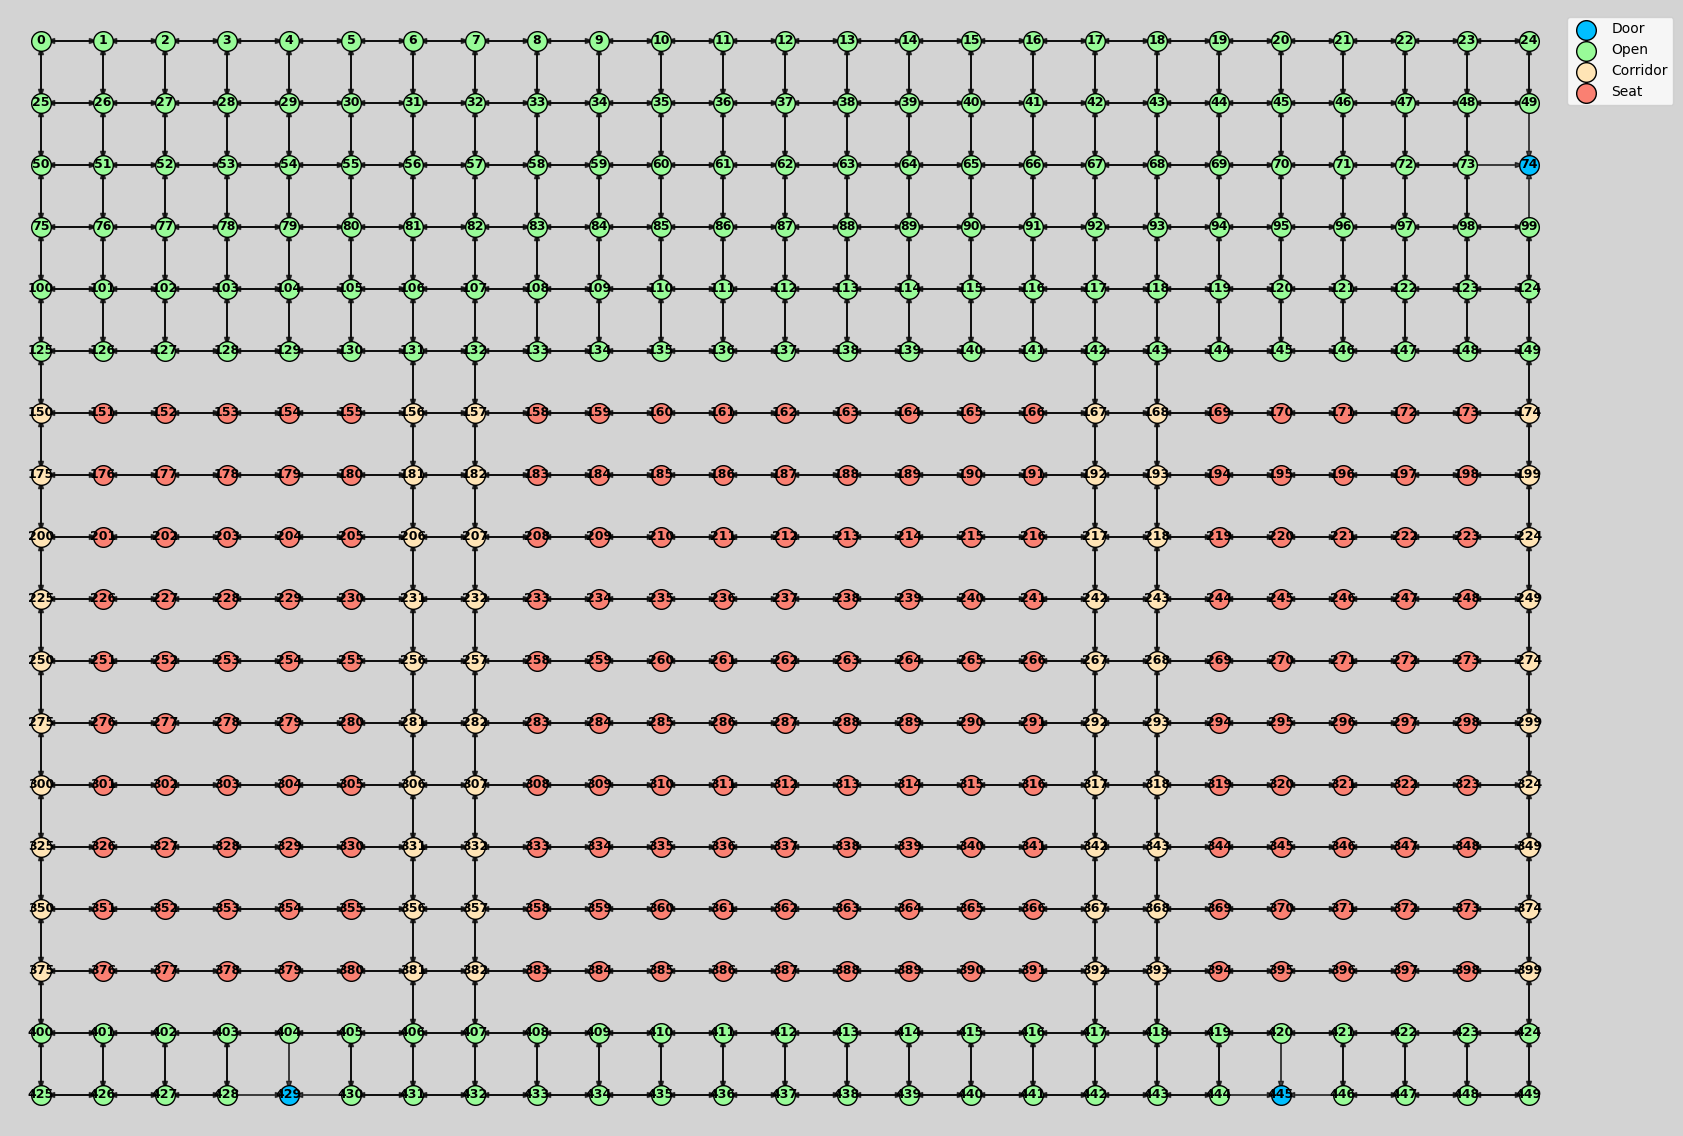

In [20]:
plot_network(df_nodes, df_links, idx_doors, X, Y, True, False, figsize=(20,20), name="image/CE1.pdf")

# Solving algorithms

In [21]:
def BPR(x, t0, c, alpha, beta):
    ratio = x / c
    demand_factor = 1 + alpha * np.pow(ratio, beta)
    t = t0 * demand_factor
    return t

### User equilibrium

In [22]:
def link_cost_function_ue(x, df_links):
    t0 = df_links["t0"].to_numpy()
    c = df_links["sat"].to_numpy()
    alpha = 0.15
    beta = 4

    t = BPR(x, t0, c, alpha, beta)
    #mask = x >= c
    #t[mask] = np.inf
    return t

def objective_function_ue(x, df_links):
    t0 = df_links["t0"].to_numpy()
    c = df_links["sat"].to_numpy()
    alpha = 0.15
    beta = 4

    integ_t = t0 * (x + (alpha / (beta+1)) * ( np.pow(x,beta+1) / np.pow(c,beta)))
    obj = np.sum(integ_t)
    return obj

In [31]:
max_iter = 5000
max_gap = 1e-4
max_gap_ls = 1e-2
link_cost_function = link_cost_function_ue
objective_function = objective_function_ue

x_star_ue, gap_ue, obj_ue = FW(max_iter, max_gap, max_gap_ls, link_cost_function, objective_function, df_od, df_links, df_nodes)

Iteration : 500 / 5000
Iteration : 1000 / 5000
Iteration : 1500 / 5000
Iteration : 2000 / 5000
Iteration : 2500 / 5000
Iteration : 3000 / 5000
Iteration : 3500 / 5000
Iteration : 4000 / 5000
Iteration : 4500 / 5000
Iteration : 5000 / 5000


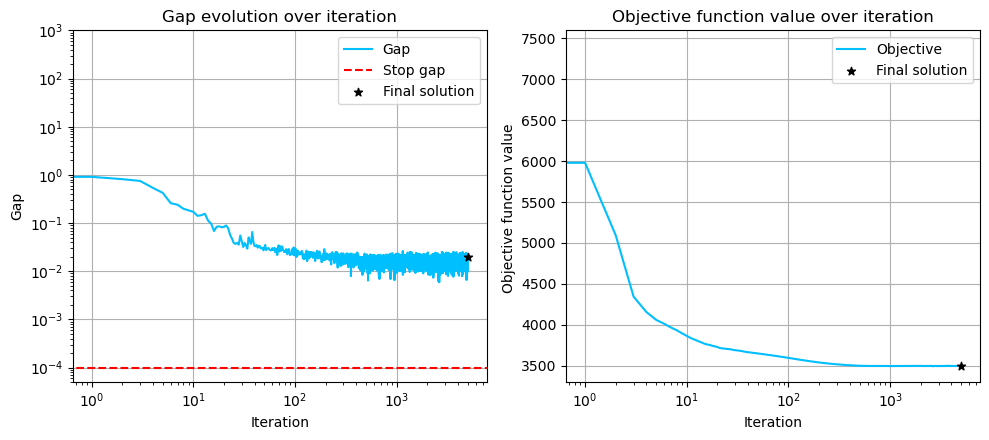

In [35]:
plt.figure(figsize=(10,4.5))

plt.subplot(1,2,1)
plt.loglog(np.arange(len(gap_ue)), gap_ue, color='Deepskyblue', label='Gap')
plt.hlines(1e-4, 0, 2*max_iter, color='red', linestyles='--', label='Stop gap')
plt.scatter(len(gap_ue)-1, gap_ue[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Gap")
plt.title("Gap evolution over iteration")
plt.ylim([5e-5, 1e3])
plt.legend()

plt.subplot(1,2,2)
plt.semilogx(np.arange(len(obj_ue)), obj_ue, color='Deepskyblue', label='Objective')
plt.scatter(len(obj_ue)-1, obj_ue[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Objective function value ")
plt.title("Objective function value over iteration")
plt.legend()

plt.tight_layout()
plt.show()

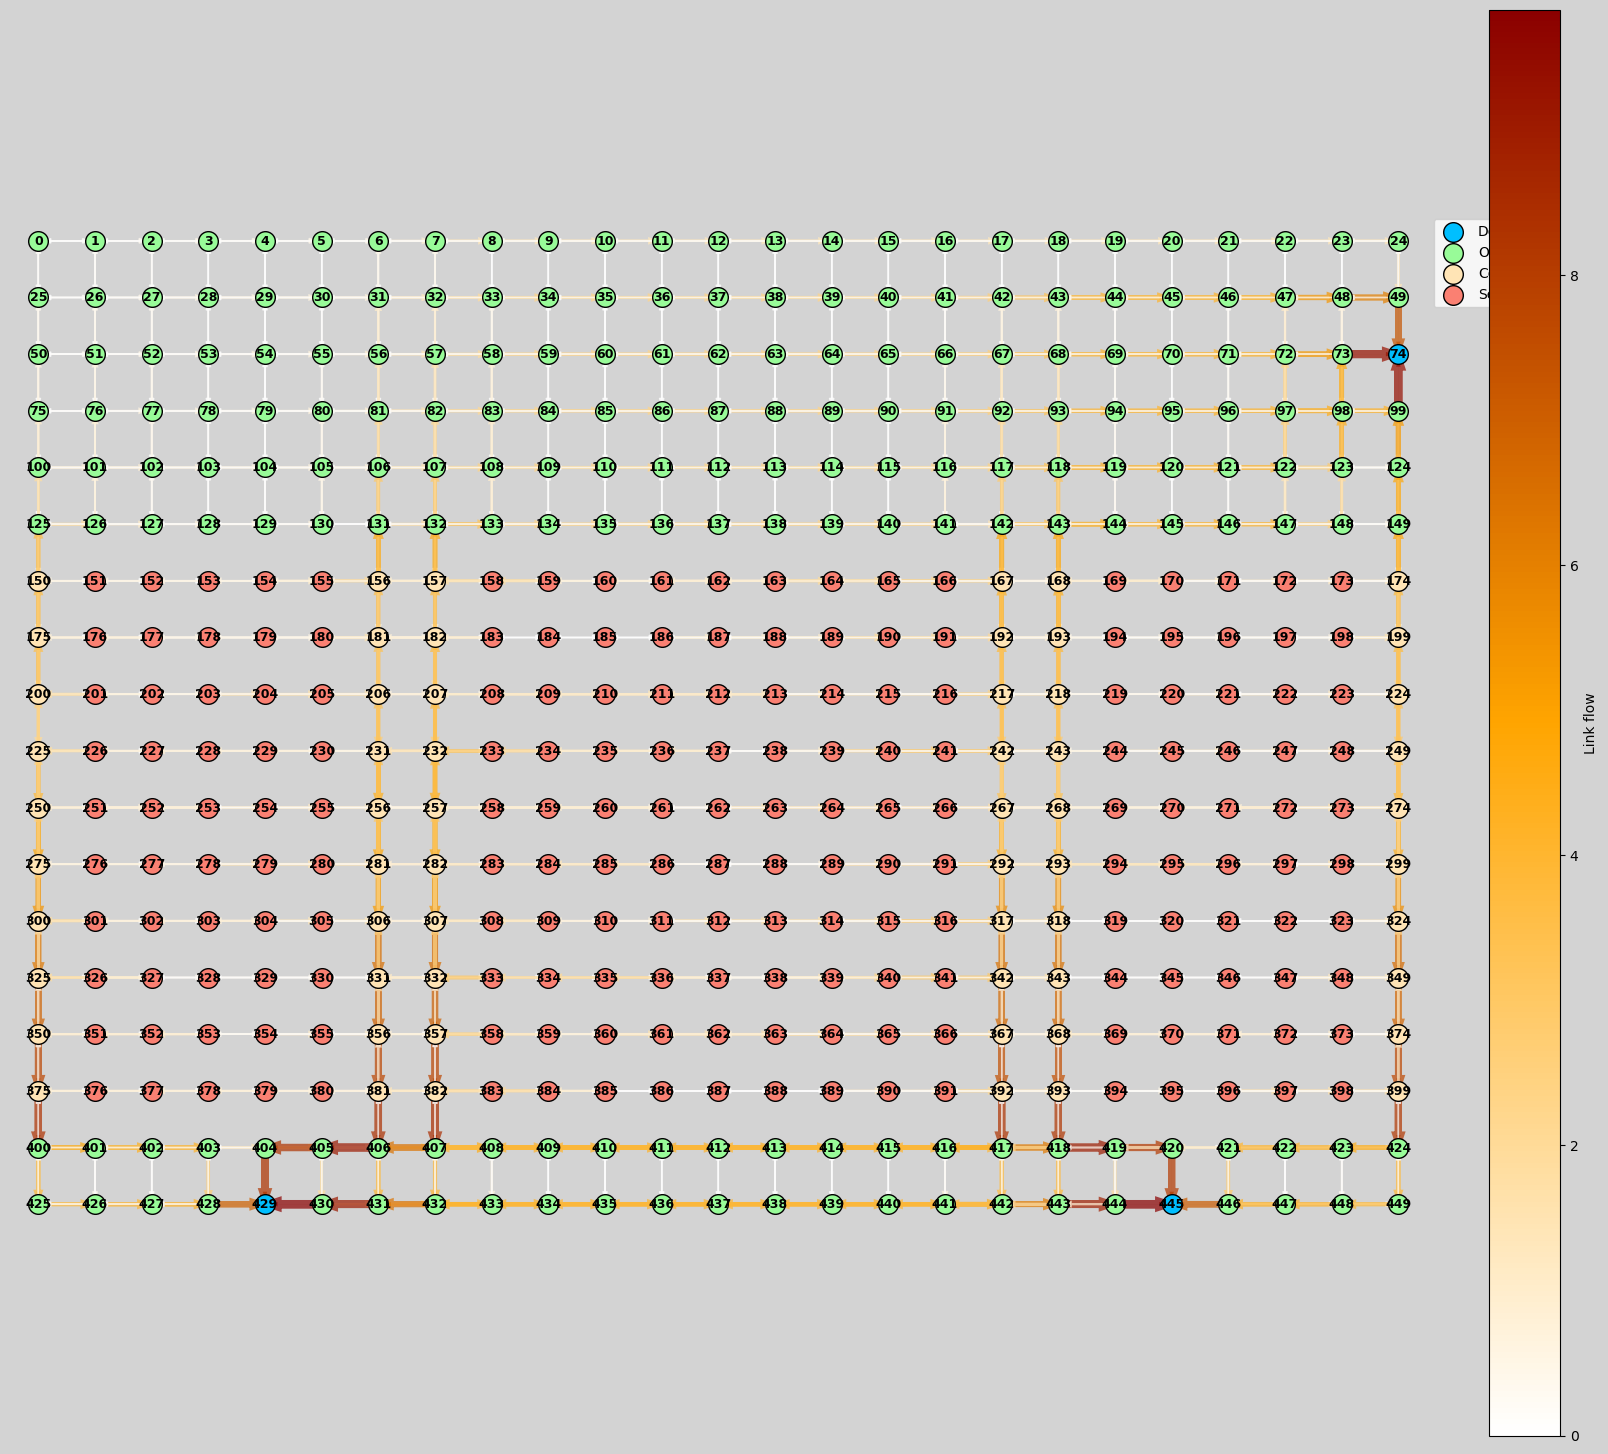

In [33]:
plot_network(df_nodes, df_links, idx_doors, X, Y, True, False, figsize=(20,20), x=x_star_ue, name="image/CE1_UE.pdf")

### System optimum

In [36]:
def link_cost_function_so(x, df_links):
    t0 = df_links["t0"].to_numpy()
    c = df_links["sat"].to_numpy()
    alpha = 0.15
    beta = 4

    tau = t0 * alpha * beta * ( np.pow(x, beta+1) / np.pow(c, beta) )
    t_bpr = BPR(x, t0, c, alpha, beta)
    t = t_bpr + x * tau
    #mask = x >= c
    #t[mask] = np.inf
    return t

def objective_function_so(x, df_links):
    t0 = df_links["t0"].to_numpy()
    c = df_links["sat"].to_numpy()
    alpha = 0.15
    beta = 4

    obj = x @ BPR(x, t0, c, alpha, beta)
    return obj

In [37]:
max_iter = 5000
max_gap = 1e-4
max_gap_ls = 1e-2
link_cost_function = link_cost_function_so
objective_function = objective_function_so

x_star_so, gap_so, obj_so = FW(max_iter, max_gap, max_gap_ls, link_cost_function, objective_function, df_od, df_links, df_nodes)

Iteration : 500 / 5000
Iteration : 1000 / 5000
Iteration : 1500 / 5000
Iteration : 2000 / 5000
Iteration : 2500 / 5000
Iteration : 3000 / 5000
Iteration : 3500 / 5000
Iteration : 4000 / 5000
Iteration : 4500 / 5000
Iteration : 5000 / 5000


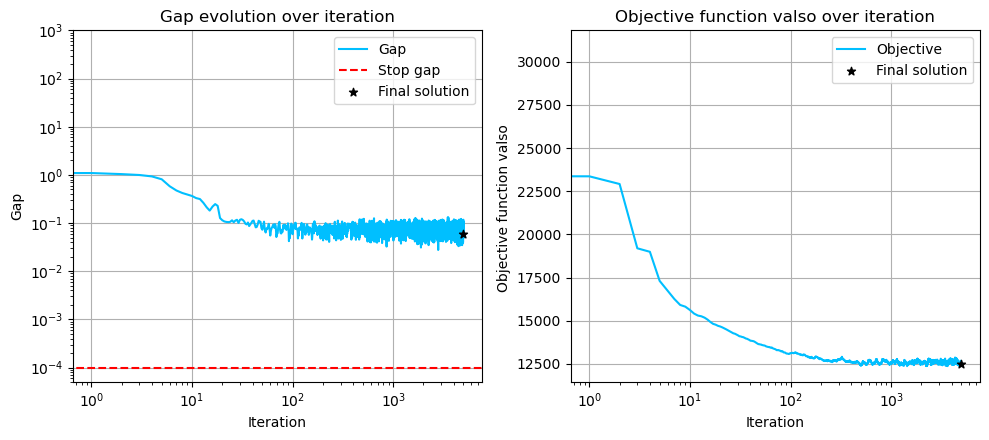

In [40]:
plt.figure(figsize=(10,4.5))

plt.subplot(1,2,1)
plt.loglog(np.arange(len(gap_so)), gap_so, color='Deepskyblue', label='Gap')
plt.hlines(1e-4, 0, 2*max_iter, color='red', linestyles='--', label='Stop gap')
plt.scatter(len(gap_so)-1, gap_so[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Gap")
plt.title("Gap evolution over iteration")
plt.ylim([5e-5, 1e3])
plt.legend()

plt.subplot(1,2,2)
plt.semilogx(np.arange(len(obj_so)), obj_so, color='Deepskyblue', label='Objective')
plt.scatter(len(obj_so)-1, obj_so[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Objective function valso ")
plt.title("Objective function valso over iteration")
plt.legend()

plt.tight_layout()
plt.show()

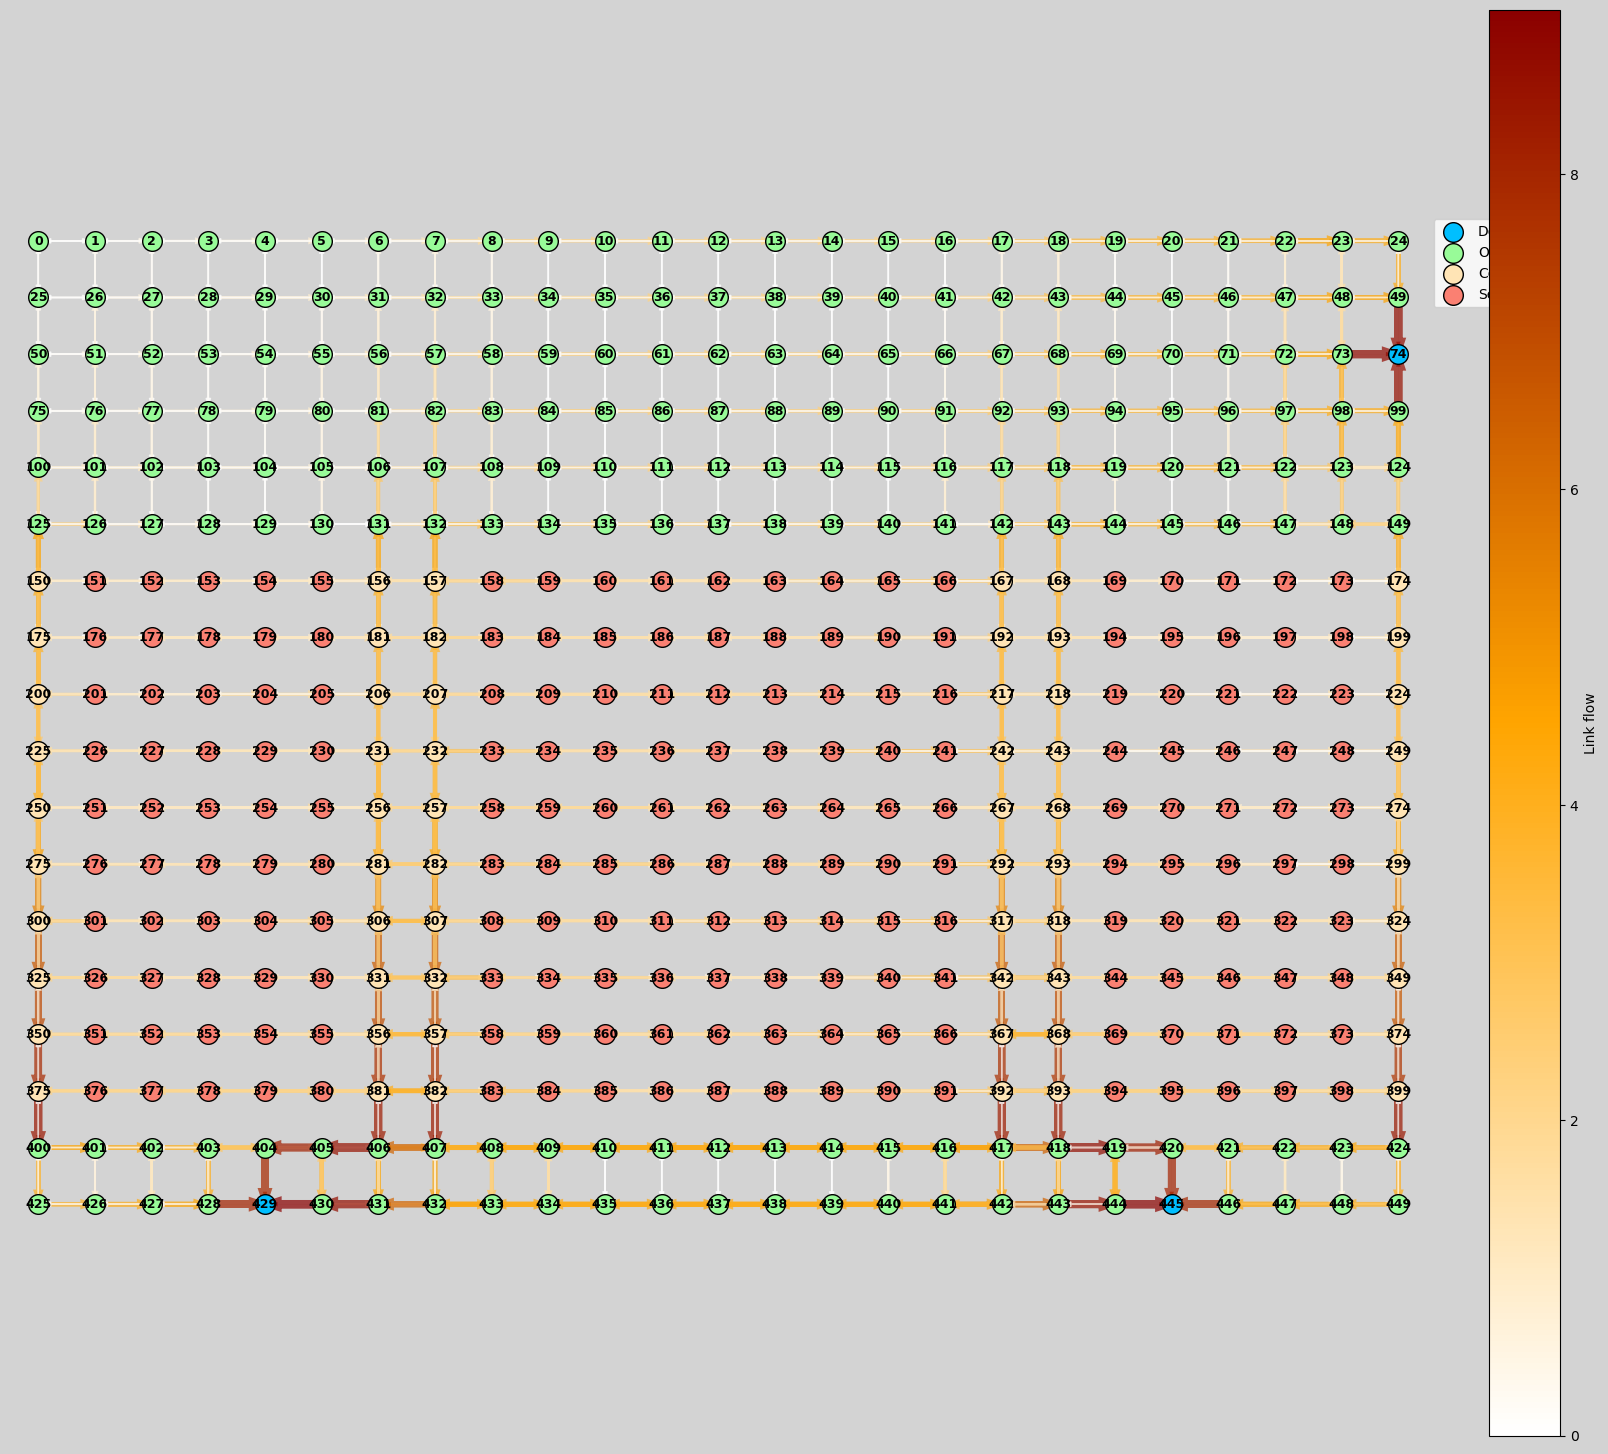

In [41]:
plot_network(df_nodes, df_links, idx_doors, X, Y, True, False, figsize=(20,20), x=x_star_so, name="image/CE1_SO.pdf")